In [1]:
!mamba install pandas matplotlib

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.46619999999925493 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [3]:
import os
os.listdir()

['Untitled.ipynb', 'README.md', 'data', 'notebooks']

In [4]:
import os
os.listdir("notebooks")

['Air_Quality_20260331.csv',
 'sqlite.ipynb',
 'r.ipynb',
 'Intro.ipynb',
 'cpp-smallpt.ipynb',
 'cpp-third-party-libs.ipynb',
 'cpp.ipynb',
 'Lorenz.ipynb']

In [5]:
df = pd.read_csv("notebooks/Air_Quality_20260331.csv")
df.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,877071,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,306308,Chelsea-Village,Summer 2023,06/01/2023,20.932670,NaN
1,877185,375,Nitrogen dioxide (NO2),Mean,ppb,CD,308,Crown Heights and Prospect Heights (CD8),Summer 2023,06/01/2023,11.870839,NaN
2,877080,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,501502,Northern SI,Summer 2023,06/01/2023,12.522830,NaN
3,876849,375,Nitrogen dioxide (NO2),Mean,ppb,Borough,2,Brooklyn,Summer 2023,06/01/2023,12.522216,NaN
4,874599,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,204,Highbridge and Concourse (CD4),Summer 2023,06/01/2023,9.288254,NaN


In [6]:
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['Unique_ID', 'Indicator_ID', 'Name', 'Measure', 'Measure_Info',
       'Geo_Type_Name', 'Geo_Join_ID', 'Geo_Place_Name', 'Time_Period',
       'Start_Date', 'Data_Value', 'Message'],
      dtype='str')

In [7]:
df["Data_Value"] = pd.to_numeric(df["Data_Value"], errors="coerce")

In [8]:
borough = df[df["Geo_Type_Name"] == "Borough"]

borough.groupby("Geo_Place_Name")["Data_Value"].mean()

Geo_Place_Name
Bronx            30.378305
Brooklyn         22.734861
Manhattan        29.704505
Queens           19.166673
Staten Island    16.641221
Name: Data_Value, dtype: float64

In [9]:
df.groupby("Time_Period")["Data_Value"].mean()

Time_Period
2005                   35.021468
2005-2007              46.218958
2009-2011              41.389583
2010                   48.055562
2011                    1.898043
2012-2014              40.144705
2013                   24.063889
2014                    1.228776
2015                   20.040972
2015-2017              34.664167
2017-2019              28.100000
2019                   52.452171
Annual Average 2009    18.363369
Annual Average 2010    16.914929
Annual Average 2011    17.377234
Annual Average 2012    15.745745
Annual Average 2013    15.222979
Annual Average 2014    15.206383
Annual Average 2015    14.696335
Annual Average 2016    13.678298
Annual Average 2017    13.711312
Annual Average 2018    13.103546
Annual Average 2019    12.166596
Annual Average 2020    11.567340
Annual Average 2021    11.882687
Annual Average 2022    11.062262
Annual Average 2023    11.787304
Summer 2009            19.313806
Summer 2010            21.690213
Summer 2011            21.17028

In [11]:
df.groupby("Geo_Place_Name")["Data_Value"].mean().sort_values(ascending=False).head(10)

Geo_Place_Name
High Bridge - Morrisania                38.107599
Hunts Point - Mott Haven                36.743714
Crotona -Tremont                        36.191883
East Harlem                             33.653890
Central Harlem - Morningside Heights    32.499754
Bronx                                   30.378305
Manhattan                               29.704505
Gramercy Park - Murray Hill             29.583835
Union Square - Lower East Side          28.881415
Stuyvesant Town and Turtle Bay (CD6)    28.362738
Name: Data_Value, dtype: float64

In [12]:
df.columns = df.columns.str.replace(" ", "_")
df["Data_Value"] = pd.to_numeric(df["Data_Value"], errors="coerce")

df.groupby("Geo_Place_Name")["Data_Value"].mean().sort_values(ascending=False).head(10)

Geo_Place_Name
High Bridge - Morrisania                38.107599
Hunts Point - Mott Haven                36.743714
Crotona -Tremont                        36.191883
East Harlem                             33.653890
Central Harlem - Morningside Heights    32.499754
Bronx                                   30.378305
Manhattan                               29.704505
Gramercy Park - Murray Hill             29.583835
Union Square - Lower East Side          28.881415
Stuyvesant Town and Turtle Bay (CD6)    28.362738
Name: Data_Value, dtype: float64

In [14]:
df.groupby("Name")["Data_Value"].mean()

Name
Annual vehicle miles traveled                             73.428646
Annual vehicle miles traveled (cars)                      67.774969
Annual vehicle miles traveled (trucks)                     3.886212
Asthma emergency department visits due to PM2.5           65.851061
Asthma emergency departments visits due to Ozone          71.866250
Asthma hospitalizations due to Ozone                      12.201875
Boiler Emissions- Total NOx Emissions                     53.791667
Boiler Emissions- Total PM2.5 Emissions                    1.373958
Boiler Emissions- Total SO2 Emissions                     10.991667
Cardiac and respiratory deaths due to Ozone                4.967083
Cardiovascular hospitalizations due to PM2.5 (age 40+)    16.773081
Deaths due to PM2.5                                       46.076558
Fine particles (PM 2.5)                                    9.045471
Nitrogen dioxide (NO2)                                    20.391861
Outdoor Air Toxics - Benzene               

In [16]:
time_avg = df.groupby("Time_Period")["Data_Value"].mean().reset_index()

time_avg["Sort_Year"] = time_avg["Time_Period"].str.extract(r'(\d{4})').astype(float)

time_avg = time_avg.sort_values("Sort_Year")

time_avg

,Time_Period,Data_Value,Sort_Year
0,2005,35.021468,2005.0
1,2005-2007,46.218958,2005.0
42,Winter 2008-09,22.191241,2008.0
2,2009-2011,41.389583,2009.0
43,Winter 2009-10,18.697837,2009.0
27,Summer 2009,19.313806,2009.0
12,Annual Average 2009,18.363369,2009.0
44,Winter 2010-11,21.704220,2010.0
13,Annual Average 2010,16.914929,2010.0
28,Summer 2010,21.690213,2010.0


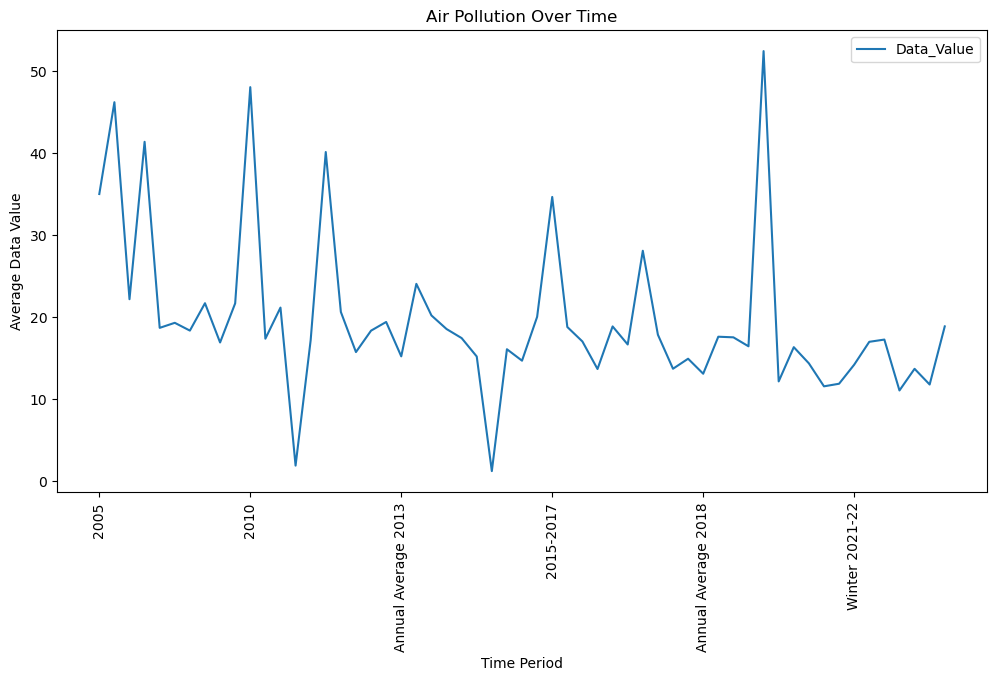

In [17]:
time_avg.plot(x="Time_Period", y="Data_Value", kind="line", figsize=(12,6))
plt.xticks(rotation=90)
plt.title("Air Pollution Over Time")
plt.xlabel("Time Period")
plt.ylabel("Average Data Value")
plt.show()

In [21]:
borough = df[df["Geo_Type_Name"] == "Borough"]

borough_avg = borough.groupby("Geo_Place_Name")["Data_Value"].mean().sort_values(ascending=False)

borough_avg

Geo_Place_Name
Bronx            30.378305
Manhattan        29.704505
Brooklyn         22.734861
Queens           19.166673
Staten Island    16.641221
Name: Data_Value, dtype: float64

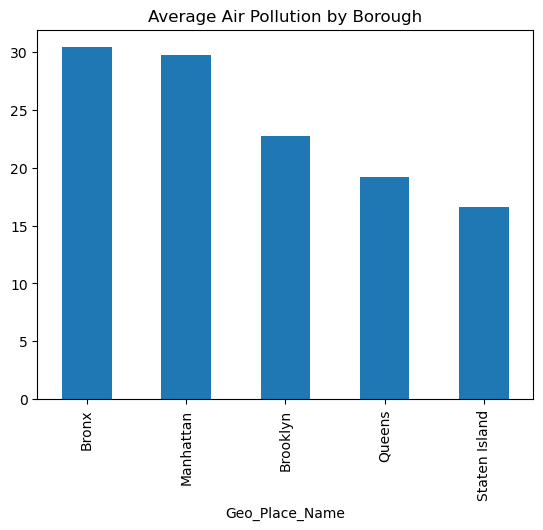

In [22]:
borough_avg.plot(kind="bar")
plt.title("Average Air Pollution by Borough")
plt.show()

In [23]:
pollutant_avg = df.groupby("Name")["Data_Value"].mean().sort_values(ascending=False)

pollutant_avg

Name
Annual vehicle miles traveled                             73.428646
Asthma emergency departments visits due to Ozone          71.866250
Annual vehicle miles traveled (cars)                      67.774969
Asthma emergency department visits due to PM2.5           65.851061
Boiler Emissions- Total NOx Emissions                     53.791667
Deaths due to PM2.5                                       46.076558
Ozone (O3)                                                30.782266
Nitrogen dioxide (NO2)                                    20.391861
Cardiovascular hospitalizations due to PM2.5 (age 40+)    16.773081
Respiratory hospitalizations due to PM2.5 (age 20+)       13.379732
Asthma hospitalizations due to Ozone                      12.201875
Boiler Emissions- Total SO2 Emissions                     10.991667
Fine particles (PM 2.5)                                    9.045471
Cardiac and respiratory deaths due to Ozone                4.967083
Annual vehicle miles traveled (trucks)     

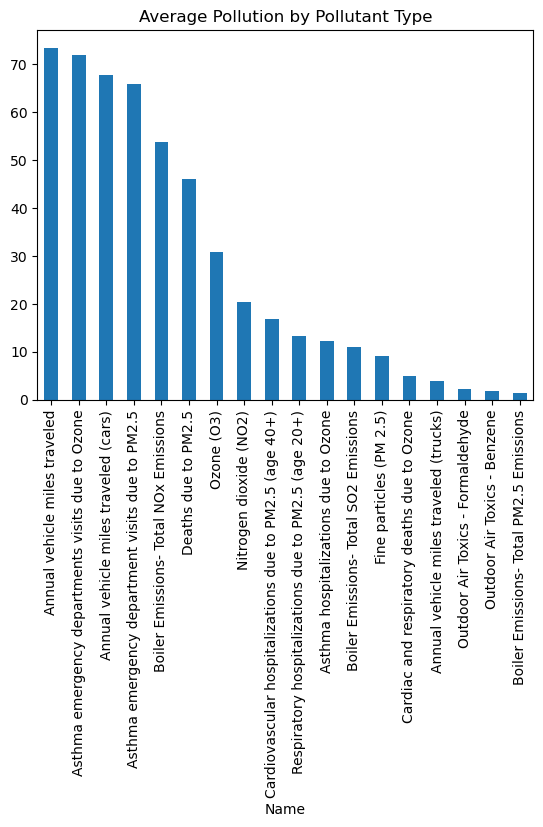

In [24]:
pollutant_avg.plot(kind="bar")
plt.title("Average Pollution by Pollutant Type")
plt.show()

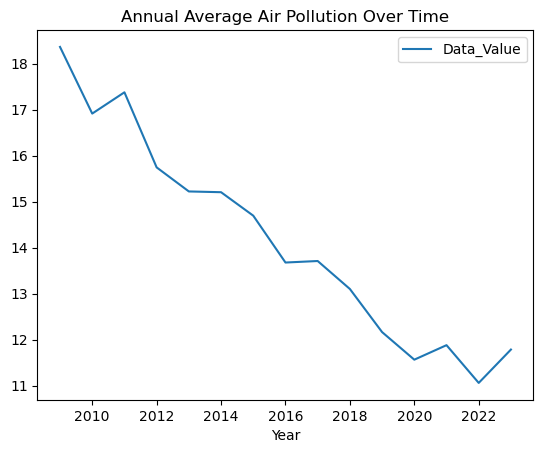

In [25]:
annual = df[df["Time_Period"].str.contains("Annual Average", na=False)].copy()

annual["Year"] = annual["Time_Period"].str.extract(r'(\d{4})').astype(int)

annual_avg = annual.groupby("Year")["Data_Value"].mean().reset_index()

annual_avg.plot(x="Year", y="Data_Value", kind="line")
plt.title("Annual Average Air Pollution Over Time")
plt.show()

In [26]:
worst_areas = df.groupby("Geo_Place_Name")["Data_Value"].mean().sort_values(ascending=False).head(10)

worst_areas

Geo_Place_Name
High Bridge - Morrisania                38.107599
Hunts Point - Mott Haven                36.743714
Crotona -Tremont                        36.191883
East Harlem                             33.653890
Central Harlem - Morningside Heights    32.499754
Bronx                                   30.378305
Manhattan                               29.704505
Gramercy Park - Murray Hill             29.583835
Union Square - Lower East Side          28.881415
Stuyvesant Town and Turtle Bay (CD6)    28.362738
Name: Data_Value, dtype: float64

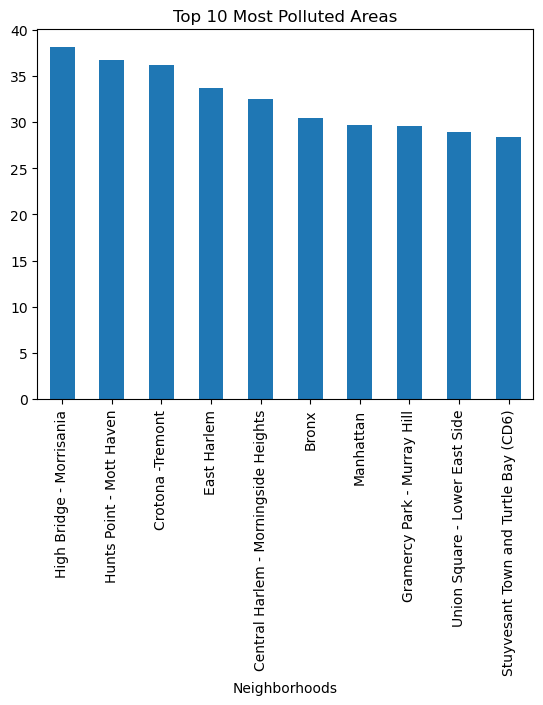

In [30]:
worst_areas.plot(kind="bar")
plt.title("Top 10 Most Polluted Areas")
plt.xlabel("Neighborhoods")
plt.show()

In [28]:
summer = df[df["Time_Period"].str.contains("Summer", na=False)]
winter = df[df["Time_Period"].str.contains("Winter", na=False)]

summer_avg = summer["Data_Value"].mean()
winter_avg = winter["Data_Value"].mean()

print("Summer avg:", summer_avg)
print("Winter avg:", winter_avg)

Summer avg: 18.731080268139163
Winter avg: 17.28475707503121
